# Python Notebook to Shift, Scale and Combine images

In [1]:
# importing all the relevant libraries 
import numpy as np
import astroalign as aa
import matplotlib.pyplot as plt
import ccdproc
import os
import astropy.io.fits as fits
from ccdproc import CCDData, combiner
from astropy import units as u
from astropy.time import Time
from photutils.aperture import CircularAperture
from photutils.aperture import aperture_photometry
from photutils.detection import DAOStarFinder
from photutils.background import Background2D
from photutils.segmentation  import detect_sources, deblend_sources, SourceCatalog
from scipy.ndimage import shift
import gc
gc.enable()

In [2]:
# ignoring warnings
import warnings
warnings.filterwarnings("ignore")

### Ensure the folders are setup correctly 
##### Create a Folder named "NGC_2547_sub"
##### Then inside that new folder, make three new folder named "b", "g", "r"

#### Input variables, select the star positions for each band

In [3]:
# positions of bright unsaturated stars
#                 star1x,star1y, star2x, star2y, star3x, star3y
positions_all = [[(603.44,1027), (807,863.08), (499.24, 855.88)], # b band positions
                 [(419, 811), (704, 871), (716, 1018)], # g band positions
                 [(418.6,807.4), (553, 1209.4), (704.2, 871)]  # r band positions
                 ]   

# selected appertures for each band
apertures_all = [15.0 , 10.0, 15.0]

# reference images for automatic alignment and scaling - need to justify these !!! - need a different one for scaling remember
aa_refidk = [0, 0, 0]

# folder name with images
im_dir = "NGC_2547_sub/"

## Python Functions

### Band Selector Variable Assignments

In [4]:
def band_sel(fidx):
    # Band Variables
    bands = ["b", "g", "r"]

    band = bands[fidx]
    fn_name = '*_'+band + '.fit'
    refidx = aa_refidk[fidx]
    return fn_name, refidx, band

# Added in 8 May ------------

## Non Uniform Background Subtraction

In [5]:
# Testing on b-band images - loading in b images
fidx = 0

In [16]:
def bkg_subtraction(fidx):
    fn_name, refidx, band = band_sel(fidx)

    # Collate images into scim and go into image path file
    images = ccdproc.ImageFileCollection(im_dir, glob_include=fn_name)

    scim = []
    newname = []
    for fn in images.files_filtered():
        scim.append(CCDData.read(im_dir + fn, unit = "adu")) 

        # Update scim with the correct time meta data
        times = scim[-1].header['DATE-OBS']                                      # Get the time
        t = Time(times, format='isot', scale='utc')                              # Read the time from UTC format
        scim[-1].header['MJD-OBS'] = (float(t.mjd), 'MJD')      

        # creating new name for automatic alignment later
        newname.extend(["aa"+fn])        

    print(band,"-band Images collected: ", len(scim))

    bkg_meds = []
    for idk, thisimage in enumerate(scim):
        # Model the data using a 50x50 box size for smoothing 
        im_bkg = Background2D(scim[idk], 50)
        # Background updating to array 
        bkg_meds = np.append(bkg_meds, im_bkg.background_median.value)

        # removing background in image
        scim[idk].data = scim[idk].data - im_bkg.background.value
    print(band, "-band Background Subtraction completed")   

    # selecting threshold value to exlude
    med_1sig = np.mean(bkg_meds) + 0.5*np.std(bkg_meds)
    print("Median background: ",np.mean(bkg_meds))
    print("Threshold background: ", med_1sig)

    # saving background median values to text file
    np.savetxt("background/"+band+"_bkg_meds.txt", bkg_meds, overwrite=True)

    return med_1sig, scim, bkg_meds, newname



### Automatic Alignment

In [17]:
def autom_align(fidx): 
    med_1sig, scim, bkg_meds, newname = bkg_subtraction(fidx)
    
    # Generate data from band of interest
    fn_name, refidx, band = band_sel(fidx)
    print("Beginning Image Alignment for ", band, " images")

    # Generate new file names                                        
    print("Aligned Image Filename: ", newname[-1]) 

    # Navigate into band folder
    #os.chdir("b_test/")
    num_excl = 0
    for idx, thisimage in enumerate(scim):
        # Define images to be shifted
        # Plus zero is a quirky fix to an endian issue (old school)
        img_ref=scim[refidx].data+0       # Reference image
        img_example=scim[idx].data+0      # Image to be shifted image
        
        if bkg_meds[idx] <= med_1sig:
            img_aligned, footprint = aa.register(img_example, img_ref, detection_sigma=5.0, min_area=9, fill_value=-99999.99)
            temp=scim[idx]
            temp.data=img_aligned
            temp.meta = scim[idx].meta
            print("Median background: ",bkg_meds[idx])
            # Write the image to a file using the new name (aa- prefix)
            temp.write("b_test/" + newname[idx], overwrite=True)
        else:
            print("Image ", idx, " excluded")
            num_excl = num_excl + 1

    # plotting background for each image
    plt.rcParams['font.family'] = 'Times New Roman'
    x = np.arange(0, len(bkg_meds))
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(x, bkg_meds, marker='o', linestyle="", markersize = 1.5)
    # Horizontal lines
    ax.axhline(med_1sig, color='green', linestyle='--', label=r'+0.5$\sigma$')
    ax.axhline(np.mean(bkg_meds), color='red', linestyle='--', label=f'Median ={np.mean(bkg_meds):.2f} ADU')
    # Green shaded region from bottom of plot to b
    ax.axhspan(ymin=ax.get_ylim()[0],ymax=med_1sig, color='green', alpha=0.2, label='Images included')
    # Labels
    ax.set_xlabel("Image number")
    ax.set_ylabel("Background Median (ADU)")
    ax.set_title(f"NGC 2547 "+band+"-band\n"+str(num_excl)+" images excluded")
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xticks(np.arange(x[0], x[-1], 10))
    plt.tight_layout()
    plt.savefig("background/background_median_plot_"+band+".png", overwrite=True)
    plt.show()

    print("Image Alignment Completed")

b -band Images collected:  282
b -band Background Subtraction completed
Median background:  1552.7074468085107
Threshold background:  1624.6281645495872
Beginning Image Alignment for  b  images
Aligned Image Filename:  aaLight_NGC_2547_10.0s_IRCUT_20260331-212023_b.fit
Image  0  excluded
Image  1  excluded
Image  2  excluded
Image  3  excluded
Image  4  excluded
Image  5  excluded
Image  6  excluded
Image  7  excluded
Image  8  excluded
Image  9  excluded
Image  10  excluded
Image  11  excluded
Image  12  excluded
Image  13  excluded
Image  14  excluded
Image  15  excluded
Image  16  excluded
Image  17  excluded
Image  18  excluded
Image  19  excluded
Image  20  excluded
Image  21  excluded
Image  22  excluded
Image  23  excluded
Image  24  excluded
Image  25  excluded
Image  26  excluded
Image  27  excluded
Image  28  excluded
Image  29  excluded
Image  30  excluded
Image  31  excluded
Image  32  excluded
Image  33  excluded
Image  34  excluded
Image  35  excluded
Image  36  excluded


TypeError: Figure.savefig() takes 2 positional arguments but 4 were given

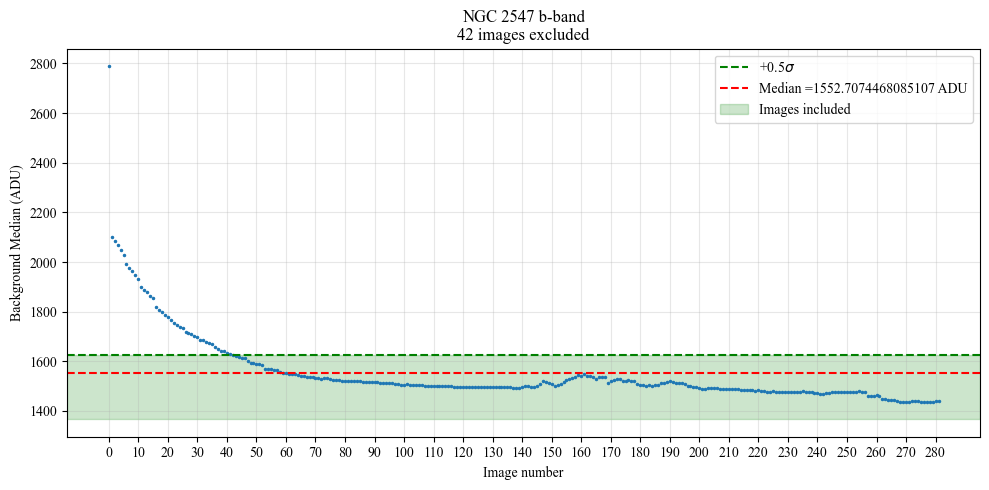

In [15]:
autom_align(fidx)

### Scaling Function

In [ ]:
def scaling(fidx):
    

### Combine Function

In [ ]:
def combine(fidx):
    phot_tables = autom_align(fidx)

    # Generate data from band of interest
    fn_name, refidx, band = band_sel(fidx)
    print("Beginning Image Combining for ", band, " images")

    images = ccdproc.ImageFileCollection(".",glob_include = fn_name)          
    scim = [CCDData.read(fn) for fn in images.files_filtered()]                         

    # This code is missing comments. What is it doing?
    for idx, thisimage in enumerate(scim):                                                          # iterating through each image        
        m = np.ma.median(phot_tables[refidx]['aperture_sum'] / phot_tables[idx]['aperture_sum'])    # scaling each image with the reference image
        print(m)
        scim[idx] = scim[idx].multiply(m * u.adu)                                                   # normalising adu counts with reference image

    os.chdir("..")
    os.chdir("..")
    # Comment on the combine operations, including why minmax_clip_min = -500    
    sci_average = ccdproc.combine(scim, method = 'average',dtype = np.float32,          # mean combining images  
                                minmax_clip = True, minmax_clip_min = -500)           # rejecting any data with -500 adu counts in the average combining
    sci_average.write(band+"_NGC_2547_av.fits", overwrite=True)

    sci_median = ccdproc.combine(scim, method = 'median',dtype = np.float32,            # median combining images
                                minmax_clip = True, minmax_clip_min = -500)
    sci_median.write(band+"_NGC_2547_med.fits", overwrite=True)

    del(scim)
    collected = gc.collect()
    print('Check garbage collection', collected)

    print(band, " Images Combining Finished")

## Executing Code
This executions completes shifting, scaling and combining for all bands. 

In [ ]:
for fidx in list(range(3)):
    combine(fidx)